<b>Introduction à l'apprentissage machine (GIF-4101 / GIF-7005)</b><img src="https://vision.gel.ulaval.ca/~cgagne/enseignement/apprentissage/A2019/ul_logo.png" width=200 align="right"><br>
<b>Département de génie électrique et de génie informatique</b><br>
<b>Automne 2019</b>

# Devoir 4

## Instructions
- Formation des équipes
    - GIF-4101 : le devoir est réalisé en équipe de deux à trois étudiants.
    - GIF-7005 : le devoir est réalisé individuellement.
- Programmation
    - Produisez vos solutions dans le notebook (.ipynb) directement, en respectant les instructions.
    - La performance attendue et le temps de calcul approximatif requis sont vérifiés dans le code, tout écart trop important par rapport à ces valeurs attendues entraînera *la note de zéro (0)* pour la sous-question correspondante.
- Remise
    - La remise du notebook (.ipynb) complété se fait dans monPortail.
    - La remise doit être effectuée au plus tard le mercredi 27 novembre à 9h30.
- Pondération
    - Ce devoir compte pour 7% de la note finale.

## Identification

- Numéro d'équipe : *69*
- Étudiant 1 : *Samaneh*, *Bidabadi*, *111255394*

## Librairies permises et fonction utilitaire
Lors de l'installation d'Anaconda, les sous-packages `torchvision` et `pytorch` ne sont pas installés par défaut. Vous pouvez les installer avec la commande `conda install pytorch torchvision -c pytorch` dans un terminal.

In [1]:
import gzip
import time
import numpy

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import SGD
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
import torchvision.transforms as T
from torch.autograd import Variable

import matplotlib
matplotlib.rcParams['figure.figsize'] = (9.0, 7.0)
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import random


def create_balanced_sampler(dataset):
    def make_weights_for_balanced_classes(images, n_classes):                        
        count = [0] * n_classes                                                      
        for item in images:                                                         
            count[item[1]] += 1                                                     
        weight_per_class = [0.] * n_classes                                      
        N = float(sum(count))                                                   
        for i in range(n_classes):                                                   
            weight_per_class[i] = N/float(count[i])                                 
        weight = [0] * len(images)                                              
        for idx, val in enumerate(images):                                          
            weight[idx] = weight_per_class[val[1]]                                  
        return weight

    n_classes = numpy.unique(dataset.targets)
    weights = make_weights_for_balanced_classes(dataset.data, len(n_classes))                                                         
    weights = torch.DoubleTensor(weights)                 
    sampler = torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights)) 
    return sampler


def compute_accuracy(model, dataloader, device='cpu'):
    training_before = model.training
    model.eval()
    all_predictions = []
    all_targets = []
    
    for i_batch, batch in enumerate(dataloader):
        images, targets = batch
        images = images.to(device)
        targets = targets.to(device)
        with torch.no_grad():
            predictions = model(images)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    if all_predictions[0].shape[-1] > 1:
        predictions_numpy = numpy.concatenate(all_predictions, axis=0)
        predictions_numpy = predictions_numpy.argmax(axis=1)
        targets_numpy = numpy.concatenate(all_targets, axis=0)
    else:
        predictions_numpy = numpy.concatenate(all_predictions).squeeze(-1)
        targets_numpy = numpy.concatenate(all_targets)
        predictions_numpy[predictions_numpy >= 0.5] = 1.0
        predictions_numpy[predictions_numpy < 0.5] = 0.0

    if training_before:
        model.train()

    return (predictions_numpy == targets_numpy).mean()


## Q1. Entraînement de réseaux de neurones à convolution (10 pts)
Pour cette question, nous vous demandons d'entraîner un réseau de neurones à convolutions sur le jeu de données [*Volcanoes on Venus*](https://www.kaggle.com/fmena14/volcanoesvenus/). Une [version abrégée du jeu de données](https://vision.gel.ulaval.ca/~cgagne/enseignement/apprentissage/A2019/travaux/volcanoes.zip) vous est fournies pour la réalisation du devoir (attention: 120 Mo).

### Q1A
Dans un premier temps, vous devez vous familiariser avec les données. Pour ce faire, vous devez définir la classe `VolcanoesDataset`, qui hérite de la classe abstraite `torch.utils.data.Dataset`. Comme mentionné dans la [documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset), vous devez surcharger les méthodes `__getitem__` et `__len__` afin d'avoir un jeu de données utilisable par PyTorch.

De plus, vous tester votre classe `VolcanoesDataset`, affichez quatre images __aléatoires__ dans une seule figure et indiquer sa classe dans le titre. Tracez également la distribution de la classe des données contenu dans le jeu d'entraînement avec un histogramme.

### <p style="color:red;">Correction de la question Q1A
Vous avez obtenu la note de 2.5/2.5

Explications (si nécessaire):


(array([6000., 1000.]), array([0. , 0.5, 1. ]), <a list of 2 Patch objects>)

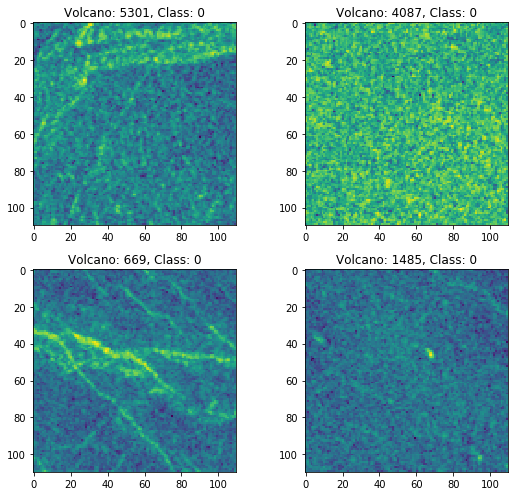

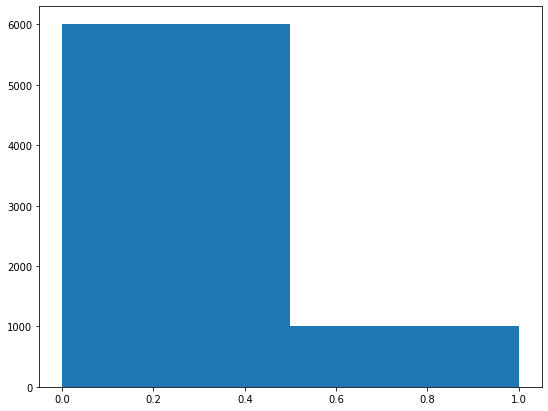

In [5]:
class VolcanoesDataset(Dataset):
    """
    Cette classe sert à définir le dataset Volcanoes pour PyTorch
    dataset venant de Francisco Mena sur kaggle : https://bit.ly/2DasPF1

    Args:
        path (str): le chemin du fichier .pt du dataset
    """
    def __init__(self, path):
        super().__init__()
        # garde les paramètres en mémoire
       
        self.path = path
        # charger les données
        with gzip.open(path, 'rb') as f:
            self.data = torch.load(f)  
            # Pour faciliter la lecture des targets
            self.targets = numpy.array(list(zip(*self.data))[1])

    def __getitem__(self, index):
         # TODO Q1A
        return self.data[index][0], self.targets[index]
    
    def __len__(self):
         # TODO Q1A
        return len(self.data)
# Creation du dataset
train_set = VolcanoesDataset('/home/mathieu/source/devoirs-iam-a2019/Volcanoes_train.pt.gz')

fig, subfigs = plt.subplots(2, 2, tight_layout=True)
    # TODO Q1A
    # Affichage des images aléatoires
for subfig in subfigs.reshape(-1):
    rand = random.randint(0,len(train_set))
    subfig.imshow(train_set[rand][0][0])
    subfig.title.set_text('Volcano: {}, Class: {}'.format(rand, train_set[rand][1]))

fig, subfig = plt.subplots()
# TODO Q1A
# Visualisation de la distribution des données dans le train_set
subfig.hist(train_set.targets, bins=2)

### Q1B
Vous devez maintenant définir une classe `VolcanoesNet` définissant les méthodes et les attributs nécessaires à l'entraînement d'un réseau de neurones sur le jeu de données *Volcanoes on Venus* selon les directives suivantes. 
 - Initialisez les couches du réseau dans la méthode `__init__`, en utilisant des couches de convolution (`Conv2D`), de normalisation (`BatchNorm2D`) et linéaire (`Linear`), selon l'architecture présentées ici-bas.
 - Pour les convolutions, vous devez respecter le nombre de filtres de convolution et la taille spécifiés dans le diagramme. Vous devez aussi, et ce pour toutes les convolutions, spécifier un _pas_ de 2 et ne pas utiliser le biais de la convolution puisque la couche de normalisation contient déjà un paramètre pour le biais. Ajustez aussi le _padding_ pour avoir une convolution _same_ (même taille d'image en entrée et en sortie).
 - Écrivez les lignes de code manquantes pour l'inférence du réseau dans la méthode `forward` du réseau `VolcanoesNet`. La couche `average_pooling` est déjà implémentée dans le code.
 
 <img src="https://vision.gel.ulaval.ca/~cgagne/enseignement/apprentissage/A2019/travaux/reseau-d4q1.png" width=800>

### <p style="color:red;">Correction de la question Q1B
Vous avez obtenu la note de 1.0/2.5

Explications (si nécessaire): Stride : 2, 2, 2,... bias = False, padding = 2, 1, 1, ...


In [9]:
class VolcanoesNet(nn.Module):
    """
    This class defines a plainly convolutional network, simple
    to classify satellite images of Venus.
    """
    def __init__(self):
        super().__init__()
        # TODO Q1B
        # Initialiser ici les modules contenant des 
        # paramètres à optimiser. Ces modules seront
        # utilisés dans la méthode 'forward'
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=5, stride=1)
        self.batch1 = torch.nn.BatchNorm2d(32)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.batch2 = torch.nn.BatchNorm2d(64)
        self.conv3 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.batch3 = torch.nn.BatchNorm2d(64)
        self.conv4 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.batch4 = torch.nn.BatchNorm2d(64)
        self.conv5 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.batch5 = torch.nn.BatchNorm2d(64)
    
        self.pool = torch.nn.AvgPool2d(kernel_size=3, stride=1)
        self.fc1 = torch.nn.Linear(589824, 2)
        
    def forward(self, x):
        # TODO Q1B
        # Exécute l'inférence du réseau. L'ordre 
        # d'exécution ici est important.
        x = F.relu(self.batch1(self.conv1(x)))
        x = F.relu(self.batch2(self.conv2(x)))
        x = F.relu(self.batch3(self.conv3(x)))
        x = F.relu(self.batch4(self.conv4(x)))
        x = F.relu(self.batch5(self.conv5(x)))
        x = self.pool(x)
        # Fait un average pooling sur les caractéristiques
        # de chaque filtre
        x = x.view(x.size(0), -1)
        # TODO Q1B
        # Couche lineaire et sigmoide
        x = F.sigmoid(self.fc1(x))
        return x

### Q1C
Il faut maintenant faire le nécessaire pour entraîner le réseau de neurones que vous venez de définir. Écrivez les lignes de code manquantes pour la préparation de l'entraînement et celles à l'intérieur de la boucle d'entraînement.

### <p style="color:red;">Correction de la question Q1C
Vous avez obtenu la note de 0/2.5

Explications (si nécessaire): Le network est trop gros pour tester...


In [10]:
%%time
from torch.autograd import Variable
# Sets whether cuda is used or not
# put cuda to use a GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print("--->"+device)
# Sets training parameters
# We recommend these parameters.
nb_epoch = 10
learning_rate = 0.01
momentum = 0.9
batch_size = 32

# Load training and test data
train_set = VolcanoesDataset('/home/mathieu/source/devoirs-iam-a2019/Volcanoes_train.pt.gz')
test_set = VolcanoesDataset('/home/mathieu/source/devoirs-iam-a2019/Volcanoes_test.pt.gz')

# Create the sampler with the balanced classes
balanced_train_sampler = create_balanced_sampler(train_set)
balanced_test_sampler = create_balanced_sampler(test_set)

# Create the dataloader for training
train_loader = DataLoader(train_set, batch_size=batch_size, sampler=balanced_train_sampler)
test_loader = DataLoader(test_set, batch_size=batch_size, sampler=balanced_test_sampler)
# TODO Q1C 
# Instancier un réseau VolcanoesNet
# dans une variable nommée "model"
model = VolcanoesNet()
# Tranfert le réseau au bon endroit
model.to(device)
# TODO Q1C
# Instancier une fonction d'erreur BinaryCrossEntropy
# et la mettre dans une variable nommée criterion

criterion = torch.nn.CrossEntropyLoss()
# TODO Q1C 
# Instancier l'algorithme d'optimisation SGD
# Ne pas oublier de lui donner les hyperparamètres
# d'entraînement : learning rate et momentum!
optimizer = SGD(model.parameters(), lr=learning_rate, momentum=momentum)
# TODO Q1C
# Mettre le réseau en mode entraînement


# TODO Q1C
# Remplir les TODO dans la boucle d'entraînement


for i_epoch in range(nb_epoch):

    start_time, train_losses = time.time(), []
    for i_batch, batch in enumerate(train_loader):
        images, targets = batch

        images = Variable(images)
        targets = Variable(targets)

        images = images.to(device)
        targets = targets.to(device)


        predictions = model(images)
        loss = criterion(predictions, targets)
        train_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(' [-] epoch {:4}/{:}, train loss {:.6f} in {:.2f}s'.format(
        i_epoch+1, nb_epoch, numpy.mean(train_losses), time.time()-start_time))

# affiche le score à l'écran
test_acc = compute_accuracy(model, test_loader, device)
print(' [-] test acc. {:.6f}%'.format(test_acc * 100))

--->cuda


/home/mathieu/.local/lib/python3.7/site-packages/torch/nn/functional.py:1350: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


KeyboardInterrupt: 

### Q1D
Afin de visualiser les performances finales de votre réseau, la matrice de confusion est particulièrement utile. La première et la deuxième rangée de la matrice de confusion présente les résultats la classe 0 et 1 respectivement. On dira que la donnée appartient à la classe 0 lorsque la probabilité en sortie est plus petite que 0.5. Expliquez brièvement les performances du réseau selon la matrice de confusion obtenue.

### <p style="color:red;">Correction de la question Q1D
Vous avez obtenu la note de 0/2.5

Explications (si nécessaire): Aucune explication, utilisation de scikit, vous devez implémenter la fonction manuellement.


C:\Users\sbida\Anaconda3\lib\site-packages\ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in true_divide


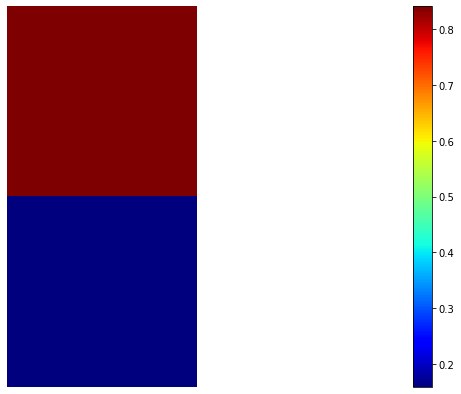

In [18]:
def compute_confusion_matrix(model, dataloader, device='cpu'):
    # TODO Q1D
    # Put the model in evaluation mode

    # Calculate all predictions on the dataloader
    all_predictions = []
    all_targets = []
    for i_batch, batch in enumerate(dataloader):
        images, targets = batch

        images = images.to(device)
        targets = targets.to(device)
        with torch.no_grad():
            predictions = model(images)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    predictions_numpy = numpy.concatenate(all_predictions, axis=0)
    predictions_numpy = predictions_numpy.argmax(axis=1)
    targets_numpy = numpy.concatenate(all_targets, axis=0)
    
    # TODO Q1D
    # Calculate the confusion matrix. Be careful to have well
    # a 2 by 2 matrix on the output
    matrix = confusion_matrix(targets_numpy, predictions_numpy)
    return matrix


test_set = VolcanoesDataset('data/volcanoes/volcanoes_test.pt.gz')
test_loader = DataLoader(test_set, batch_size=batch_size)
matrix = compute_confusion_matrix(model, test_loader, device='cpu')
print(matrix)
plt.imshow(matrix/matrix.sum(axis=0), cmap = 'jet');
plt.colorbar();
plt.axis('off');

#### Réponse Q1D
*Expliquez brièvement les performances du réseau selon la matrice de confusion obtenue.*

## Q2. Transfert de représentation (5 pts)
Nous vous demandons maintenant de programmer un cas de transfert de représentation. Pour ce faire, nous utiliserons le réseau *ResNet-18* préalablement entraîné sur le jeu d'images naturelles *ImageNet*. On vous demande de modifier ce réseau en remplaçant seulement la tête du réseau pour l'adapter au nouveau jeu de données à 16 classes [*Lego Brick*](https://www.kaggle.com/joosthazelzet/lego-brick-images), qui est [disponible sur le site Web du cours](https://vision.gel.ulaval.ca/~cgagne/enseignement/apprentissage/A2019/travaux/lego.zip) (attention: 190 Mo). Vous devriez être en mesure d'atteindre de très bonnes performance sur ce jeu en seulement une époque d'entraînement.

### Q2A
Changez la dernière couche pleinement connectée du réseau de neurone (couche `fc`) afin de l'adapter au nombre de classes du jeu de données (16 classes ici). De plus, gelez les autres couches du réseau *ResNet-18* se trouvant avant la nouvelle couche pleinement connectée de sortie. Écrivez également la ligne de code nécessaire à l'inférence du réseau dans la méthode `forward`.

### <p style="color:red;">Correction de la question Q2A
Vous avez obtenu la note de 0/5

Explications (si nécessaire): Bugs


In [2]:
class LegoNet(nn.Module):

    def __init__(self, pretrained=False):
        super().__init__()
        # Crée le réseau de neurone pré-entraîné
        self.model = resnet18(pretrained=pretrained)
        # Récupère le nombre de neurones avant
        # la couche de classification
        dim_before_fc = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features=512, out_features=16, bias=True)
        # TODO Q2A
        # Changer la dernière fully-connected layer
        # pour avoir le bon nombre de neurones de
        # sortie
        if pretrained:
            # TODO Q2A
            # Geler les paramètres qui ne font pas partie
            # de la dernière couche fc
            # Conseil: utiliser l'itérateur named_parameters()
            # et la variable requires_grad
            for name, child in self.model.named_children():
                if name != fc:
                    for name2, params in child.named_parameters():
                        print(name2)
                        params.requires_grad = False

    def forward(self, x):
        # TODO Q2A
        # Appeler la fonction forward du réseau
        # pré-entraîné (resnet18) de LegoNet
        x = self.model.forward(x)
        return x
    
LegoNet(True)

NameError: name 'fc' is not defined

### Q2B
Écrivez les lignes de code manquantes pour la préparation de l'entraînement et celles à l'intérieur de la boucle d'entraînement selon deux modes:
1. Entraînez le réseau en exécutant le code **sans** pré-entraînement, le réseau devrait être entraîné en moins de 30 minutes sur cpu.
2. Entraînez le réseau en exécutant le code **avec** pré-entraînement (*fine tuning*).

### <p style="color:red;">Correction de la question Q2B
Vous avez obtenu la note de 0/2.5

Explications (si nécessaire): Attention, les données ne sont pas mélangé pour l'entraînement.


In [ ]:
from torch.autograd import Variable
def train(pretrained):
    # Defines whether cuda is used or not
    # set cuda to use a GPU
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Sets training parameters
    # We recommend these parameters. Now, you can
    # change them
    nb_epoch = 1
    learning_rate = 0.01
    momentum = 0.9
    batch_size = 64

    # Defines the transformations needed for
    # loading dataset
    totensor = T.ToTensor()
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    composition = T.Compose([totensor, normalize])

    # Loads the training dataset
    train_set = ImageFolder(data/lego/train', transform=composition)

    # Selects 10% of the test game randomly to lighten the calculation
    test_set = ImageFolder(data/lego/test', transform=composition)
    idx = numpy.random.randint(0, len(test_set), int(0.1 * len(test_set)))
    test_set.samples = [test_set.samples[i] for i in idx]
    

    # TODO Q2B
    # Create pytorch dataloaders with the
    # DataLoader class of pytorch
#    balanced_train_sampler = create_balanced_sampler(train_set)    
#    balanced_test_sampler = create_balanced_sampler(test_set)
    train_loader = DataLoader(train_set, batch_size=batch_size)#, sampler=balanced_train_sampler)
    test_loader = DataLoader(test_set, batch_size=batch_size)#, sampler=balanced_test_sampler)
    
    # TODO Q2B
    # Instanciating a LegoNet network
    # in a variable called "model"
    model = LegoNet()
    
    # Ttransfers the network to the right place
    model.to(device)

    # TODO Q2B
    # Instanciate a CrossEntropyLoss error function
    # and put it in a variable called criterion
    criterion = torch.nn.CrossEntropyLoss()


    # TODO Q2B
    # Instanciating the SGD optimization algorithm
    # Tip: Filter unfrozen settings!
    # Don't forget to give it hyperparameters
    # training: learning rate and momentum!
    optimizer = SGD(model.parameters(), lr=learning_rate, momentum=momentum)


    # TODO Q2B
    # put the network into training mode
 

    # Recovers the total number of batches for an epoch
    total_batch = len(train_loader)

    # TODO Q2B
    # Fill the TODOs in training loop
    for i_epoch in range(nb_epoch):

        start_time, train_losses = time.time(), []
        for i_batch, batch in enumerate(train_loader):
            images, targets = batch

            images = images.to(device)
            targets = targets.to(device)

            # TODO Q2B
            # set the gradients to zero
            optimizer.zero_grad()

            # TODO Q2B
            # Calculate:
            # 1. inference in a variable "predictions"
            # 2. Error in a variable "loss"
            predictions = model(images)
            loss = criterion(predictions, Variable(targets))

            # TODO Q2B
            # Backpropagate the error  and perform
            # an optimization step
            loss.backward()
            optimizer.step()

            # Adds the loss of the batch
            train_losses.append(loss.item())

            print(' [-] batch {:4}/{:4} since {:.2f}s'.format(
                i_batch+1, total_batch, time.time()-start_time))

        print(' [-] epoch {:4}/{:}, train loss {:.6f} in {:.2f}s'.format(
            i_epoch+1, nb_epoch, numpy.mean(train_losses), time.time()-start_time))

    # shows the score on the screen
    test_acc = compute_accuracy(model, test_loader, device)
    if pretrained:
        print(' [-] pretrained test acc. {:.6f}%'.format(test_acc * 100))
    else:
        print(' [-] not pretrained test acc. {:.6f}%'.format(test_acc * 100))

In [ ]:
# Doing training without the pre-trained model
train(pretrained=False)

In [ ]:
# Doing training with the pre-trained model
train(pretrained=True)

## Q3. Connaissance de la librairie PyTorch (5 pts)
Répondez brièvement aux questions suivantes.

### Q3A
Quelle est la différence majeure entre un objet de type `Dataset` et un objet `DataLoader`?


### <p style="color:red;">Correction de la question Q3A
Vous avez obtenu la note de 1/1

Explications (si nécessaire):


#### Réponse Q3A
Dataset read and transform a datapoint in a dataset. Since we often read datapoints in batches, we use DataLoader to shuffle and batch data. Then it load the data in parallel using multiprocessing workers. 

### Q3B
Quelle différence y a-t-il entre les méthodes dans `torch.nn` et `torch.nn.functional`? Par exemple, entre `torch.nn.Conv2d` et `torch.nn.functional.conv2d`.

### <p style="color:red;">Correction de la question Q3B
Vous avez obtenu la note de 1/1

Explications (si nécessaire):


#### Réponse Q3B
In PyTorch, we use torch.nn to build layers. For example, in `__init__`, we configure different trainable layers including convolution and affine layers with nn.Conv2d and nn.Linear respectively. We create the method forward to compute the network output. It contains functionals linking layers already configured in `__init__` to form a computation graph. Functionals include ReLU and max poolings. The difference between torch.nn and torch.nn.functional is very subtle. In fact, many torch.nn.functional have a corresponding equivalent in torch.nn. For layers with trainable parameters, we use torch.nn to create the layer. We store it back in the instance so we can easily access the layer and the trainable parameters later.

### Q3C
Pourquoi est-ce important de mettre les gradients de l'optimiseur à zéro entre chaque itération?

### <p style="color:red;">Correction de la question Q3C
Vous avez obtenu la note de 1/1

Explications (si nécessaire):


#### Réponse Q3C
We explicitly need to call zero_grad() because, after loss.backward() (when gradients are computed), we need to use optimizer.step() to proceed gradient descent. More specifically, the gradients are not automatically zeroed because these two operations, loss.backward() and optimizer.step(), are separated, and optimizer.step() requires the just computed gradients.
In addition, sometimes, we need to accumulate gradient among some batches; to do that, we can simply call backward multiple times and optimize once.

### Q3D
En une phrase, quelle opération est effectuée lorsque `loss.backward()` est exécutée.

### <p style="color:red;">Correction de la question Q3D
Vous avez obtenu la note de 1/1

Explications (si nécessaire):


#### Réponse Q3D
It's for backpropagation. In other words,to backpropogate the error all we have to do is to loss.backward(). You need to clear the existing gradients though, else gradients will be accumulated to existing gradients

### Q3E
Pourquoi est-ce si important de balancer les données pour entraîner un réseau?

### <p style="color:red;">Correction de la question Q3E
Vous avez obtenu la note de 1/1

Explications (si nécessaire):


#### Réponse Q3E
Imbalanced data refers to a situation where the number of observations is not the same for all the classes in a classification dataset.for Prediction, this will cause a definite bias. And worse, it will be a permanent bias, in the sense that we will not have consistent estimates as the sample size grows.
